In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Professional ML Libraries
from sklearn.datasets import load_iris


from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline



In [18]:
pwd

'c:\\Users\\logis\\course_2026'

In [3]:
iris = load_iris()

type(iris)

sklearn.utils._bunch.Bunch

In [17]:
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [15]:
data = iris["data"]
target = iris["target"]

In [16]:
target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [8]:
type(data)

numpy.ndarray

In [19]:
iris["data"].shape, iris["data"][0], iris["target"][0]

((150, 4), array([5.1, 3.5, 1.4, 0.2]), np.int64(0))

In [10]:
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
    
 # Add the target column and map numbers to actual species names
df['species'] = iris.target
df['species_name'] = df['species'].map({i: name for i, name in enumerate(iris.target_names)})


In [20]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica


In [11]:
print("--- Dataset Dimensions ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")
print("--- First 5 Rows ---")
print(df.head(), "\n")
print("--- Summary Statistics ---")
print(df.describe().T, "\n") # Transposed for better readability

--- Dataset Dimensions ---
Rows: 150, Columns: 6

--- First 5 Rows ---
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        0       setosa  
4        0       setosa   

--- Summary Statistics ---
                   count      mean       std  min  25%   50%  75%  max
sepal length (cm)  150.0  5.843333  0.828066  4.3  5.1  5.80  6.4  7.9
sepal width (cm)   150.0  3.057333  0.435866  2.0  2.8  3.00  3.3  4.4
petal length (cm)  150.0  3.758000  1.765298  1.0  1.6  

Generating Pairplot...


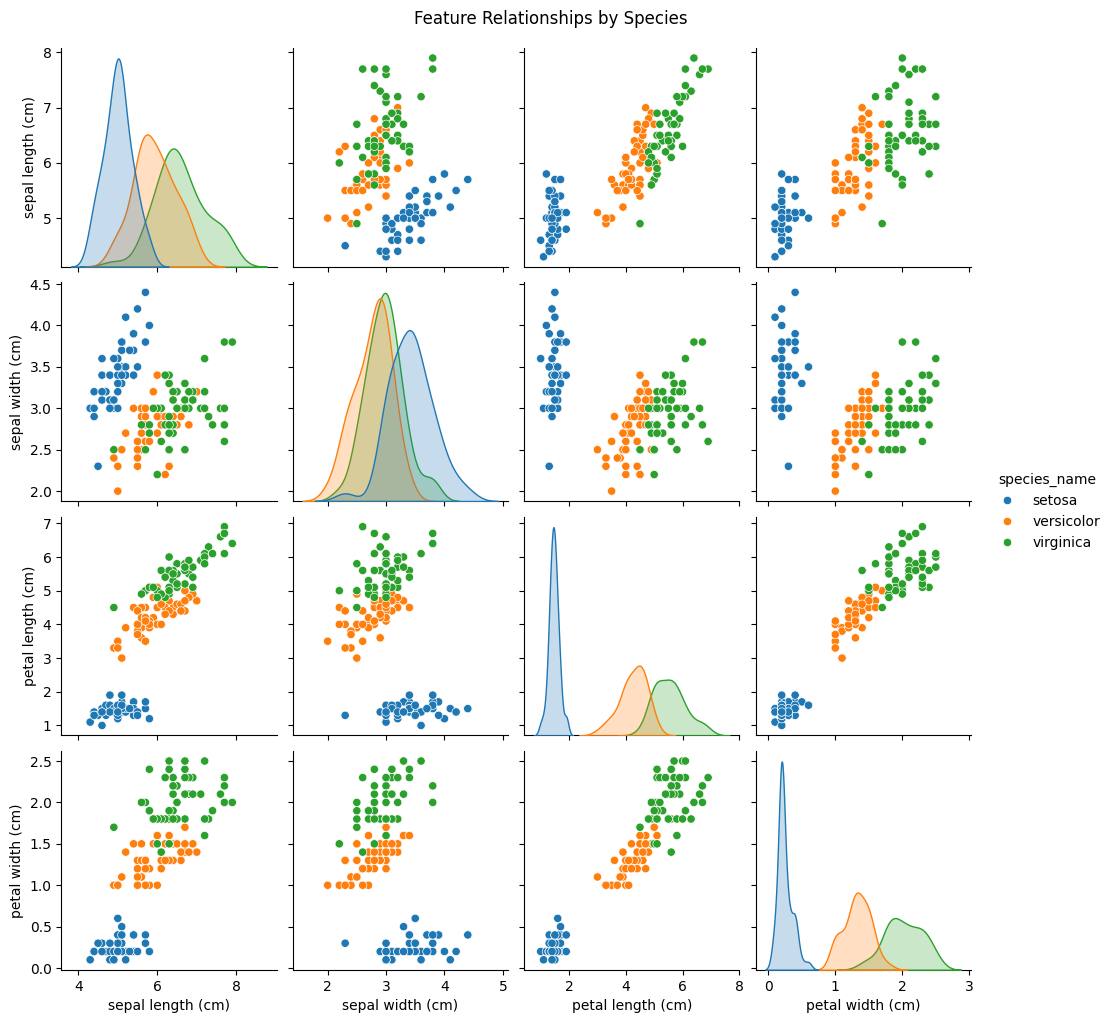

In [12]:
print("Generating Pairplot...")
pair_plot = sns.pairplot(df.drop('species', axis=1), hue='species_name', height=2.5)
pair_plot.fig.suptitle("Feature Relationships by Species", y=1.02)
plt.show()

    # B.

In [ ]:
# Separate Features (X) and Target (y)
X = iris.data
y = iris.target

# Split with 'stratify=y' to ensure equal species representation in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")


Training set size: 105 samples
Testing set size: 45 samples


In [23]:
# Build a Pipeline: Scaler -> Model
# This ensures scaling is applied correctly to test data later
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

# Training the model
pipeline.fit(X_train, y_train)
print("Pipeline trained with K=5.")

Pipeline trained with K=5.


In [28]:
# predicting on the test 
y_pred = pipeline.predict(X_test[0].reshape(1, -1))
y_pred, y_test[0]

(array([2]), np.int64(2))

In [ ]:
X_test[0]

array([7.3, 2.9, 6.3, 1.8])